In [13]:
import pandas as pd
pd.set_option('display.max_columns', 10)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, HTML
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.neighbors import NearestNeighbors
from nltk.tokenize import sent_tokenize
from sklearn.pipeline import Pipeline
import joblib

In [14]:
df = pd.read_parquet('books.parquet')
df.shape

data = df.copy()

In [15]:
#info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13120 entries, 0 to 13119
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            13120 non-null  str    
 1   title             13120 non-null  str    
 2   series            5926 non-null   str    
 3   author            13120 non-null  str    
 4   rating            13120 non-null  float64
 5   description       12798 non-null  str    
 6   language          12135 non-null  str    
 7   isbn              13120 non-null  str    
 8   genres            13120 non-null  str    
 9   characters        13120 non-null  str    
 10  bookFormat        12760 non-null  str    
 11  edition           1228 non-null   str    
 12  pages             12488 non-null  str    
 13  publisher         12179 non-null  str    
 14  publishDate       12902 non-null  str    
 15  firstPublishDate  7808 non-null   str    
 16  awards            13120 non-null  str    
 17  numR

In [16]:
# null values can be seen, let's check
df.isna().sum()

bookId                  0
title                   0
series               7194
author                  0
rating                  0
description           322
language              985
isbn                    0
genres                  0
characters              0
bookFormat            360
edition             11892
pages                 632
publisher             941
publishDate           218
firstPublishDate     5312
awards                  0
numRatings              0
ratingsByStars          0
likedPercent          152
setting                 0
coverImg              156
bbeScore                0
bbeVotes                0
price                3580
dtype: int64

In [17]:
#head
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
0,8272246-mummy-told-me-not-to-tell,Mummy Told Me Not to Tell,NaN,Cathy Glass,4.36,...,[],https://i.gr-assets.com/images/S/compressed.ph...,81,1,3.19
1,39980.A_Year_Down_Yonder,A Year Down Yonder,A Long Way from Chicago #2,Richard Peck,4.12,...,['Illinois (United States)'],https://i.gr-assets.com/images/S/compressed.ph...,84,1,7.58


In [18]:
#duplicates by title and author
df.duplicated(subset= [ 'title' , 'author']).sum()

np.int64(4)

In [19]:
#check those duplicates
df[df.duplicated(subset= [ 'title' , 'author'])]

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
7008,8438589-the-creatures-that-time-forgot,The Creatures That Time Forgot,NaN,Ray Bradbury,4.18,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,NaN
9422,650584.Shadowdale,Shadowdale,Forgotten Realms: Avatar #1,"Scott Ciencin, Richard Awlinson (Avatar Projec...",3.71,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,4.80
9478,8794263-promises-to-keep,Promises to Keep,NaN,Ann Tatlock,3.94,...,['Illinois (United States)'],https://i.gr-assets.com/images/S/compressed.ph...,87,1,4.23
12433,2669775-el-siglo-de-las-luces,El siglo de las luces,NaN,Alejo Carpentier,4.13,...,[],https://i.gr-assets.com/images/S/compressed.ph...,87,1,0.90


In [20]:
#drop duplicates
df.drop_duplicates(subset= [ 'title' , 'author'], keep = 'first', inplace = True)

# EDA

In [21]:
# all categorical columns
df.select_dtypes(include = ['str','object']).head(2)

,bookId,title,series,author,description,...,awards,ratingsByStars,setting,coverImg,price
0,8272246-mummy-told-me-not-to-tell,Mummy Told Me Not to Tell,NaN,Cathy Glass,When Reece arrives at Cathy's door at 7 years ...,...,[],"['2279', '1249', '528', '99', '23']",[],https://i.gr-assets.com/images/S/compressed.ph...,3.19
1,39980.A_Year_Down_Yonder,A Year Down Yonder,A Long Way from Chicago #2,Richard Peck,Mary Alice remembers childhood summers packed ...,...,"['Newbery Medal (2001)', ""Dorothy Canfield Fis...","['11968', '9380', '4890', '1125', '528']",['Illinois (United States)'],https://i.gr-assets.com/images/S/compressed.ph...,7.58


In [22]:
# columns : pages and price are of string types where as it should be numerical,
df['pages'] = pd.to_numeric(df['pages'], errors = 'coerce') #pages will be converted to float
df['price'] = pd.to_numeric(df['price'], errors = 'coerce') #price will be converted to float



In [23]:
# numerical columns
df.select_dtypes(include = ['number']).head(2)



,rating,pages,numRatings,likedPercent,bbeScore,bbeVotes,price
0,4.36,344.0,4178,97.0,81,1,3.19
1,4.12,160.0,27891,94.0,84,1,7.58


In [24]:
# Let's plot images of the top 30 books with highest liked percentage

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Highest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent', ascending=False).head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [25]:
# Let's plot images of the top 30 books with lowest likedPercent

# Collect valid image URLs in a list

display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 30 Books by Lowest Liked Percentage</h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/>"
        f"<div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='likedPercent').head(30)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [26]:
df['bookFormat'].value_counts()

bookFormat
Paperback                6759
Hardcover                3037
Kindle Edition           1435
Mass Market Paperback     637
ebook                     629
                         ... 
Other Format                1
Diary                       1
Paperback/Kindle            1
Taschenbuch                 1
audiobook                   1
Name: count, Length: 64, dtype: int64

In [27]:
# plotting 20 most expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Most Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=False).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


In [28]:
# plotting 20 least expensive books
display(HTML(
    "<div style='display:flex; flex-direction:column; align-items:flex-start;'>"
    "<h2 style='margin-bottom:15px;'>Top 20 Least Expensive Books </h2>"
    "<div style='display:grid; grid-template-columns:repeat(8, 1fr); gap:10px;'>"
    + "".join([
        f"<div style='display:flex; flex-direction:column; align-items:center;'>"
        f"<img src='{link}' style='height:200px;'/><div style='max-width:110px;text-align:center;font-size:14px;margin-top:4px;'>{title}</div>"
        f"</div>"
        for title, link in df.sort_values(by='price', ascending=True).head(20)[['title', 'coverImg']].values
      ])
    + "</div></div>"
))


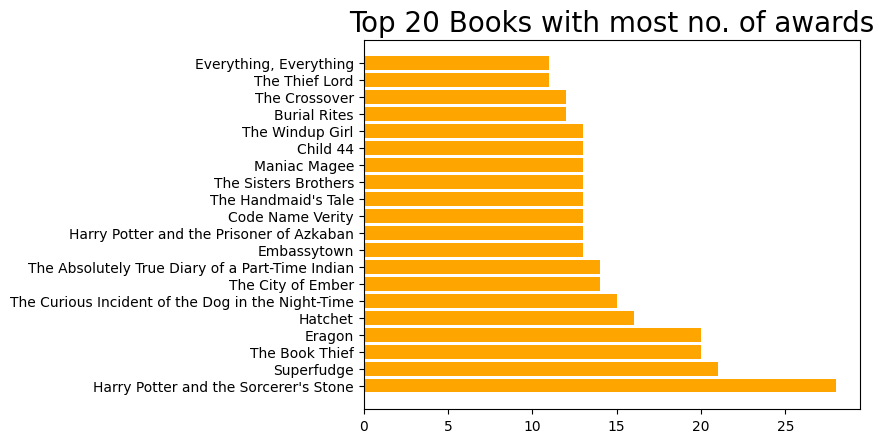

In [29]:
# Get titles and award counts for the top 20 books with most awards
no_of_awards = df['awards'].str.replace('[','').str.replace(']','').str.split(',').apply(lambda lst: len([x.strip() for x in lst if x.strip() != ''])).sort_values(ascending = False).head(20)
ax = plt.barh(width= no_of_awards.values, y = df.loc[no_of_awards.index,'title'], color = 'orange')
plt.plot(figsize = (10,10), ax =ax)
plt.title('Top 20 Books with most no. of awards', size = 20);



In [30]:
df.language.value_counts()

language
English                                  10614
Arabic                                     252
Spanish                                    160
French                                     155
German                                     131
Indonesian                                 119
Portuguese                                  82
Italian                                     69
Dutch                                       59
Turkish                                     56
Persian                                     42
Polish                                      32
Japanese                                    29
Greek, Modern (1453-)                       29
Swedish                                     27
Russian                                     26
Bengali                                     22
Romanian                                    21
Malay                                       19
Danish                                      14
Norwegian                                   13
Czec

In [31]:
df.characters[0]

'[]'

# Feature Engineering

In [32]:
df.head(2)

,bookId,title,series,author,rating,...,setting,coverImg,bbeScore,bbeVotes,price
0,8272246-mummy-told-me-not-to-tell,Mummy Told Me Not to Tell,NaN,Cathy Glass,4.36,...,[],https://i.gr-assets.com/images/S/compressed.ph...,81,1,3.19
1,39980.A_Year_Down_Yonder,A Year Down Yonder,A Long Way from Chicago #2,Richard Peck,4.12,...,['Illinois (United States)'],https://i.gr-assets.com/images/S/compressed.ph...,84,1,7.58


In [33]:
# we will use only few columns
df = df[['title','author','description','genres', 'coverImg']]
df.head()

,title,author,description,genres,coverImg
0,Mummy Told Me Not to Tell,Cathy Glass,When Reece arrives at Cathy's door at 7 years ...,"['Nonfiction', 'Abuse', 'Memoir', 'Biography',...",https://i.gr-assets.com/images/S/compressed.ph...
1,A Year Down Yonder,Richard Peck,Mary Alice remembers childhood summers packed ...,"['Historical Fiction', 'Young Adult', 'Fiction...",https://i.gr-assets.com/images/S/compressed.ph...
2,Lucid Intervals,Stuart Woods,A brand-new page-turning Stone Barrington nove...,"['Mystery', 'Fiction', 'Thriller', 'Suspense',...",https://i.gr-assets.com/images/S/compressed.ph...
3,The Disenchantments,Nina LaCour (Goodreads Author),Colby and Bev have a long-standing pact: gradu...,"['Young Adult', 'Contemporary', 'Music', 'Fict...",https://i.gr-assets.com/images/S/compressed.ph...
4,The Deadhouse,Linda Fairstein (Goodreads Author),One of the most haunting buildings in New York...,"['Mystery', 'Fiction', 'Crime', 'Thriller', 'M...",https://i.gr-assets.com/images/S/compressed.ph...


In [34]:
#check null values in filtered df
df.isna().sum()

title            0
author           0
description    322
genres           0
coverImg       156
dtype: int64

In [35]:
#drop null
df.dropna(inplace = True)

In [36]:
#check null again
df.isna().sum()

title          0
author         0
description    0
genres         0
coverImg       0
dtype: int64

In [37]:
df.shape

(12700, 5)

In [38]:
# preprocess genres
df.genres = df.genres.str.lower().str.replace(' ','').apply(eval).str.join(' ') #removing spaces between words

In [39]:
# preprocess author
df['author'] = df['author'].str.replace(' ','').str.replace(',',' ') #removing spaces between name and surname 

df['author'] = df['author'].str.replace(r'\(.+\)','',regex = True).str.replace(r'\s+',' ',regex = True).str.strip() #removing parentheses

df['author'] = df['author'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip() #removing punctuations



In [40]:
# preprocessing description
stop = r'\b('+ '|'.join(stopwords.words('english'))+r')\b'  # stopwords with regex

df['description'] = df['description'].str.lower().str.replace(stop,' ',regex = True) # removing stopwords




In [41]:
#create new column : tags = author + description + genres
df['tags'] = df['author'] + ' ' + df['description'] + ' ' + df['genres']
df.head()

,title,author,description,genres,coverImg,tags
0,Mummy Told Me Not to Tell,cathyglass,"reece arrives cathy' door 7 years old, ...",nonfiction abuse memoir biography truecrime fo...,https://i.gr-assets.com/images/S/compressed.ph...,cathyglass reece arrives cathy' door 7 ...
1,A Year Down Yonder,richardpeck,mary alice remembers childhood summers packed ...,historicalfiction youngadult fiction childrens...,https://i.gr-assets.com/images/S/compressed.ph...,richardpeck mary alice remembers childhood sum...
2,Lucid Intervals,stuartwoods,brand-new page-turning stone barrington nove...,mystery fiction thriller suspense mysterythril...,https://i.gr-assets.com/images/S/compressed.ph...,stuartwoods brand-new page-turning stone bar...
3,The Disenchantments,ninalacour,"colby bev long-standing pact: graduate, ...",youngadult contemporary music fiction roadtrip...,https://i.gr-assets.com/images/S/compressed.ph...,ninalacour colby bev long-standing pact:...
4,The Deadhouse,lindafairstein,"one haunting buildings new york city, ...",mystery fiction crime thriller mysterythriller...,https://i.gr-assets.com/images/S/compressed.ph...,lindafairstein one haunting buildings ...


In [42]:
#preprocess tags
df['tags'] = df['tags'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(r'\s+',' ',regex = True).str.strip()  #removing punctuations

In [43]:
#stemming
ps = PorterStemmer()
df['tags'] =df['tags'].str.split(' ').apply(lambda x:[ps.stem(i) for i in x])

df.tags = df.tags.str.join(' ')  # list to text

In [44]:
#tag vectorization
tfidf = TfidfVectorizer(max_features=6000, stop_words = 'english')
vec = tfidf.fit_transform(df['tags']).toarray()

In [45]:
# top 10 similar using nearest neighbors
nn = NearestNeighbors(metric = 'cosine', n_neighbors=10)
nn.fit(vec)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [46]:
_,indices = nn.kneighbors(tfidf.transform([' door end silent corridor haunt harri pottter dream els would wake middl night scream terrorharri lot mind fifth year hogwart defens dark art teacher person like poison honey big surpris gryffindor quidditch team loom terror ordinari wizard level exam thing pale next grow threat must name threat neither magic govern'.lower()]).toarray())

In [47]:
df.iloc[indices.flatten()]

,title,author,description,genres,coverImg,tags
307,Harry Potter and the Prisoner of Azkaban,jkrowling marygrandpr,harry potter' third year hogwarts full ...,fantasy youngadult fiction magic childrens adv...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr harri potter third year hog...
6204,Harry Potter and the Chamber of Secrets,jkrowling marygrandpr,ever since harry potter come home summer...,fantasy youngadult fiction magic childrens mid...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr ever sinc harri potter come...
11470,Harry Potter and the Sorcerer's Stone,jkrowling marygrandpr,harry potter' life miserable. parents d...,fantasy fiction youngadult magic childrens mid...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl marygrandpr harri potter life miser par...
10377,James Potter and the Morrigan Web,gnormanlippert,"james potter returns hogwarts wake ""...",fantasy fiction youngadult magic fanfiction ad...,https://i.gr-assets.com/images/S/compressed.ph...,gnormanlippert jame potter return hogwart wake...
2846,Harry Potter Schoolbooks Box Set: Two Classic ...,jkrowling,alternate cover edition isbn13 .fan...,fantasy fiction youngadult childrens magic sci...,https://i.gr-assets.com/images/S/compressed.ph...,jkrowl altern cover edit isbn13 fan harri pott...
3809,Spellsinger,alandeanfoster,"among sentient animals humans, hardheaded ...",fantasy fiction humor sciencefictionfantasy sc...,https://i.gr-assets.com/images/S/compressed.ph...,alandeanfost among sentient anim human hardhea...
6477,The Unofficial Harry Potter Cookbook: From Cau...,dinahbucholz,"bangers mash harry, ron, hermione ho...",cookbooks nonfiction cooking food reference fo...,https://i.gr-assets.com/images/S/compressed.ph...,dinahbucholz banger mash harri ron hermion hog...
6610,The Misenchanted Sword,lawrencewattevans,ethshar northern empire war hundre...,fantasy fiction humor magic sciencefictionfant...,https://i.gr-assets.com/images/S/compressed.ph...,lawrencewattevan ethshar northern empir war hu...
2243,The Potted Quiz: Volume Eight,andyrose,potted quiz volume eight multiple choice...,,https://i.gr-assets.com/images/S/compressed.ph...,andyros pot quiz volum eight multipl choic qui...
12391,Courage,mollyevangeline,"determined follow elohim, makilien fac...",fantasy youngadult christian christianfantasy ...,https://i.gr-assets.com/images/S/compressed.ph...,mollyevangelin determin follow elohim makilien...


In [48]:
#creating pipeline
pipeline = Pipeline([
    ('vectorizer', tfidf),
    ('nn', nn)
])

In [49]:
#test pipline
pipeline.named_steps['nn'].kneighbors(
    pipeline.named_steps['vectorizer'].transform(["magic dark fear school magic stick students fairy tale adventure"]),
    return_distance=True
)


(array([[0.60716068, 0.65120494, 0.67605565, 0.71473873, 0.73136011,
         0.74292429, 0.74671386, 0.75489848, 0.75618217, 0.76918046]]),
 array([[ 3134,  5515,  9990, 11203,  2542,  6395,  8307,  4316,  3776,
          1817]]))

In [51]:
df.iloc[[3134,  5515,  9990, 11203,  2542,  6395,  8307,  4316,  3776,
          1817]]

,title,author,description,genres,coverImg,tags
3240,The Parchment,sketa,ethan looks onto neighbour' roof top ...,,https://i.gr-assets.com/images/S/compressed.ph...,sketa ethan look onto neighbour roof top find ...
5702,The Last Herald-Mage,mercedeslackey,"last herald-mage contains magic' pawn, magi...",fantasy fiction sciencefictionfantasy magic ep...,https://i.gr-assets.com/images/S/compressed.ph...,mercedeslackey last heraldmag contain magic pa...
10316,White Cat,hollyblack,extraordinary new adult fantasy magic ...,fantasy youngadult urbanfantasy paranormal mag...,https://i.gr-assets.com/images/S/compressed.ph...,hollyblack extraordinari new adult fantasi mag...
11568,False Memory,deankoontz,' fear paralyzing falling. terrifyin...,horror fiction thriller mystery suspense myste...,https://i.gr-assets.com/images/S/compressed.ph...,deankoontz fear paralyz fall terrifi dark horr...
2629,The Magician's Land,levgrossman,"quentin coldwater cast fillory, secr...",fantasy fiction magic urbanfantasy audiobook s...,https://i.gr-assets.com/images/S/compressed.ph...,levgrossman quentin coldwat cast fillori secre...
6605,The Tale of Tom Kitten,beatrixpotter,tale tom kitten set cottage garden b...,childrens picturebooks classics fiction animal...,https://i.gr-assets.com/images/S/compressed.ph...,beatrixpott tale tom kitten set cottag garden ...
8579,Home,sarahprineas,fourth book acclaimed magic thief series...,fantasy middlegrade magic adventure youngadult...,https://i.gr-assets.com/images/S/compressed.ph...,sarahprinea fourth book acclaim magic thief se...
4461,Skin Hunger,kathleenduey sheilarayyan,"sadima lives world magic banned, lea...",fantasy youngadult magic fiction youngadultfan...,https://i.gr-assets.com/images/S/compressed.ph...,kathleenduey sheilarayyan sadima live world ma...
3907,Sylvie Asleton and the Shrike's Curse,jamestcallum,girl suffers magical affliction misf...,fantasy urbanfantasy witches magic,https://i.gr-assets.com/images/S/compressed.ph...,jamestcallum girl suffer magic afflict misfort...
1887,First King of Shannara,terrybrooks,outcast druids devotion forbidden ...,fantasy fiction epicfantasy sciencefictionfant...,https://i.gr-assets.com/images/S/compressed.ph...,terrybrook outcast druid devot forbidden art m...


In [ ]:
#dump model
# joblib.dump(pipeline,'book_recommender.HDF5', compress=9)   #using compression because of large size

['book_recommender.HDF5']